# Modelo lineal multivariado y transformaciones de datos

## 1. Variables de oferta

In [2]:
import pandas as pd
import seaborn.objects as so
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

In [3]:
macro = pd.read_csv("../Notebooks/Datasets-20260209/macro_full_columns.csv")
macro.head()

,Unnamed: 0,Anio,FBKF.Construcciones.Priv_Publ,FBKF.Equi_Dur_Prod.Mat_Transp.Nac,FBKF.Equi_Dur_Prod.Mat_Transp.Import,FBKF.Equi_Dur_Prod.Maqui_YEqui.Nac,FBKF.Equi_Dur_Prod.Maqui_YEqui.Import,Consumo.Hogares,Consumo.Gobierno,Exportaciones,...,PBI_a_precios_de_mercado.oferta,Vol_PIB_perCap,Vol_Consumo_Hogares_Per_Cap,Vol_FBKF_perCap,PIB_perCap__variPorc,Vol_Cons_Hogares_per_Cap__vari_Porc,Vol_FBKF_perCap__variPorc,Vol_PIB_encaden_Fisher_2004,IPI_volumen,IPI__variPorc
0,1,1950,20353627362,6.685869e+08,5.844002e+08,3119383475,8.631124e+08,1.046560e+11,21706316451,1.072959e+10,...,1.420980e+11,8230.718755,6061.927168,1265.389774,NaN,NaN,NaN,1.420980e+11,0.292917,NaN
1,2,1951,21739314091,8.427402e+08,2.532758e+09,3562534310,1.292775e+09,1.105380e+11,21767097618,8.455494e+09,...,1.474360e+11,8360.967138,6268.494407,1442.153759,0.015825,0.034076,0.139691,1.474360e+11,0.303920,0.037563
2,3,1952,19685428171,1.119084e+09,1.484422e+09,3440750327,1.088416e+09,1.051080e+11,21455589059,6.224082e+09,...,1.404910e+11,7806.866125,5840.680245,1293.154332,-0.066272,-0.068248,-0.103317,1.404910e+11,0.289604,-0.047104
3,4,1953,20237375978,1.207891e+09,1.459989e+09,3621895632,8.869267e+08,1.064030e+11,20742065172,9.619869e+09,...,1.473240e+11,8027.665603,5797.868309,1290.488829,0.028283,-0.007330,-0.002061,1.473240e+11,0.303689,0.048637
4,5,1954,19372130307,1.173452e+09,8.059002e+08,4121320340,7.830799e+08,1.143920e+11,21238933697,1.020162e+10,...,1.533160e+11,8196.878491,6115.886428,1230.475866,0.021079,0.054851,-0.046504,1.533160e+11,0.316039,0.040667


In [4]:
cols = [c for c in macro.columns if c.endswith(".oferta")]
cols

['Agricultura_caza_silvicultura_y_pesca.oferta',
 'Explotacion_de_minas_y_canteras.oferta',
 'Industria_manufacturera.oferta',
 'Electricidad_gas_y_agua.oferta',
 'Construccion.oferta',
 'Comercio_hoteles_y_restaurantes.oferta',
 'Transp_Almac_y_Comunics.oferta',
 'Inter_Fin_Seg_Activ_Inmo_Serv_Empr_etc.oferta',
 'Servs_Socs_Comunales_Y_Personales.oferta',
 'Impuesto_Prod_Netos_De_Subsid.oferta',
 'PBI_a_precios_de_mercado.oferta']

In [5]:
macro_oferta = macro[cols]
macro_oferta.head()

,Agricultura_caza_silvicultura_y_pesca.oferta,Explotacion_de_minas_y_canteras.oferta,Industria_manufacturera.oferta,Electricidad_gas_y_agua.oferta,Construccion.oferta,Comercio_hoteles_y_restaurantes.oferta,Transp_Almac_y_Comunics.oferta,Inter_Fin_Seg_Activ_Inmo_Serv_Empr_etc.oferta,Servs_Socs_Comunales_Y_Personales.oferta,Impuesto_Prod_Netos_De_Subsid.oferta,PBI_a_precios_de_mercado.oferta
0,13696637358,1452011417,3.230475e+10,198218385.1,5918090281,2.528165e+10,7262970408,1.955076e+10,2.174366e+10,1.469771e+10,1.420980e+11
1,14629457210,1686941522,3.314928e+10,212725994.5,6060937395,2.626086e+10,7534071597,1.990274e+10,2.236844e+10,1.539495e+10,1.474360e+11
2,12545616104,1794762161,3.252291e+10,227896262.1,5571363747,2.441732e+10,7017131008,2.059880e+10,2.257738e+10,1.464870e+10,1.404910e+11
3,16402296333,1925706862,3.234105e+10,242404260.9,5546340195,2.400975e+10,7210541490,2.071623e+10,2.307222e+10,1.525787e+10,1.473240e+11
4,16308747029,2037374129,3.490353e+10,263839496.4,5308705373,2.549291e+10,7558082163,2.127848e+10,2.379781e+10,1.607831e+10,1.533160e+11


In [6]:
# Veo si hay datos faltantes
macro_oferta.isna().any(axis=0)

Agricultura_caza_silvicultura_y_pesca.oferta     False
Explotacion_de_minas_y_canteras.oferta           False
Industria_manufacturera.oferta                   False
Electricidad_gas_y_agua.oferta                   False
Construccion.oferta                              False
Comercio_hoteles_y_restaurantes.oferta           False
Transp_Almac_y_Comunics.oferta                   False
Inter_Fin_Seg_Activ_Inmo_Serv_Empr_etc.oferta    False
Servs_Socs_Comunales_Y_Personales.oferta         False
Impuesto_Prod_Netos_De_Subsid.oferta             False
PBI_a_precios_de_mercado.oferta                  False
dtype: bool

In [7]:
pbi = macro_oferta.pop("PBI_a_precios_de_mercado.oferta")

In [8]:
pbi.head()

0    1.420980e+11
1    1.474360e+11
2    1.404910e+11
3    1.473240e+11
4    1.533160e+11
Name: PBI_a_precios_de_mercado.oferta, dtype: float64

In [9]:
macro_oferta.head()

,Agricultura_caza_silvicultura_y_pesca.oferta,Explotacion_de_minas_y_canteras.oferta,Industria_manufacturera.oferta,Electricidad_gas_y_agua.oferta,Construccion.oferta,Comercio_hoteles_y_restaurantes.oferta,Transp_Almac_y_Comunics.oferta,Inter_Fin_Seg_Activ_Inmo_Serv_Empr_etc.oferta,Servs_Socs_Comunales_Y_Personales.oferta,Impuesto_Prod_Netos_De_Subsid.oferta
0,13696637358,1452011417,3.230475e+10,198218385.1,5918090281,2.528165e+10,7262970408,1.955076e+10,2.174366e+10,1.469771e+10
1,14629457210,1686941522,3.314928e+10,212725994.5,6060937395,2.626086e+10,7534071597,1.990274e+10,2.236844e+10,1.539495e+10
2,12545616104,1794762161,3.252291e+10,227896262.1,5571363747,2.441732e+10,7017131008,2.059880e+10,2.257738e+10,1.464870e+10
3,16402296333,1925706862,3.234105e+10,242404260.9,5546340195,2.400975e+10,7210541490,2.071623e+10,2.307222e+10,1.525787e+10
4,16308747029,2037374129,3.490353e+10,263839496.4,5308705373,2.549291e+10,7558082163,2.127848e+10,2.379781e+10,1.607831e+10


In [10]:
type(pbi)

pandas.core.series.Series

In [11]:
reg = LinearRegression()
reg.fit(macro_oferta, pbi)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
reg.coef_, reg.intercept_

(array([0.94374455, 0.5151104 , 1.15932809, 2.56015043, 1.66202994,
        0.48694256, 1.20117958, 0.99930253, 1.1122599 , 0.92650163]),
 np.float64(2561320052.25531))

In [13]:
pbi_pred = reg.predict(macro_oferta)
pbi_pred

array([1.42404728e+11, 1.47154838e+11, 1.42460680e+11, 1.47218554e+11,
       1.53087196e+11, 1.63057868e+11, 1.68112710e+11, 1.76874167e+11,
       1.87676222e+11, 1.76524292e+11, 1.90094309e+11, 2.03089009e+11,
       1.99456847e+11, 1.96407801e+11, 2.14908549e+11, 2.33202595e+11,
       2.37092098e+11, 2.44360070e+11, 2.56432456e+11, 2.77398133e+11,
       2.90263358e+11, 3.01804345e+11, 3.07834528e+11, 3.17329515e+11,
       3.37281587e+11, 3.33359567e+11, 3.30349397e+11, 3.53732770e+11,
       3.39911023e+11, 3.64962827e+11, 3.69183394e+11, 3.49122931e+11,
       3.43070666e+11, 3.58173643e+11, 3.62822586e+11, 3.36765205e+11,
       3.59825056e+11, 3.71120869e+11, 3.63967879e+11, 3.37176367e+11,
       3.29271313e+11, 3.60799317e+11, 3.89599897e+11, 4.10542366e+11,
       4.34358791e+11, 4.22836105e+11, 4.45687211e+11, 4.81321990e+11,
       4.99429921e+11, 4.81196641e+11, 4.76629357e+11, 4.55825422e+11,
       4.06255706e+11, 4.45295573e+11, 4.85466107e+11, 5.28745678e+11,
      

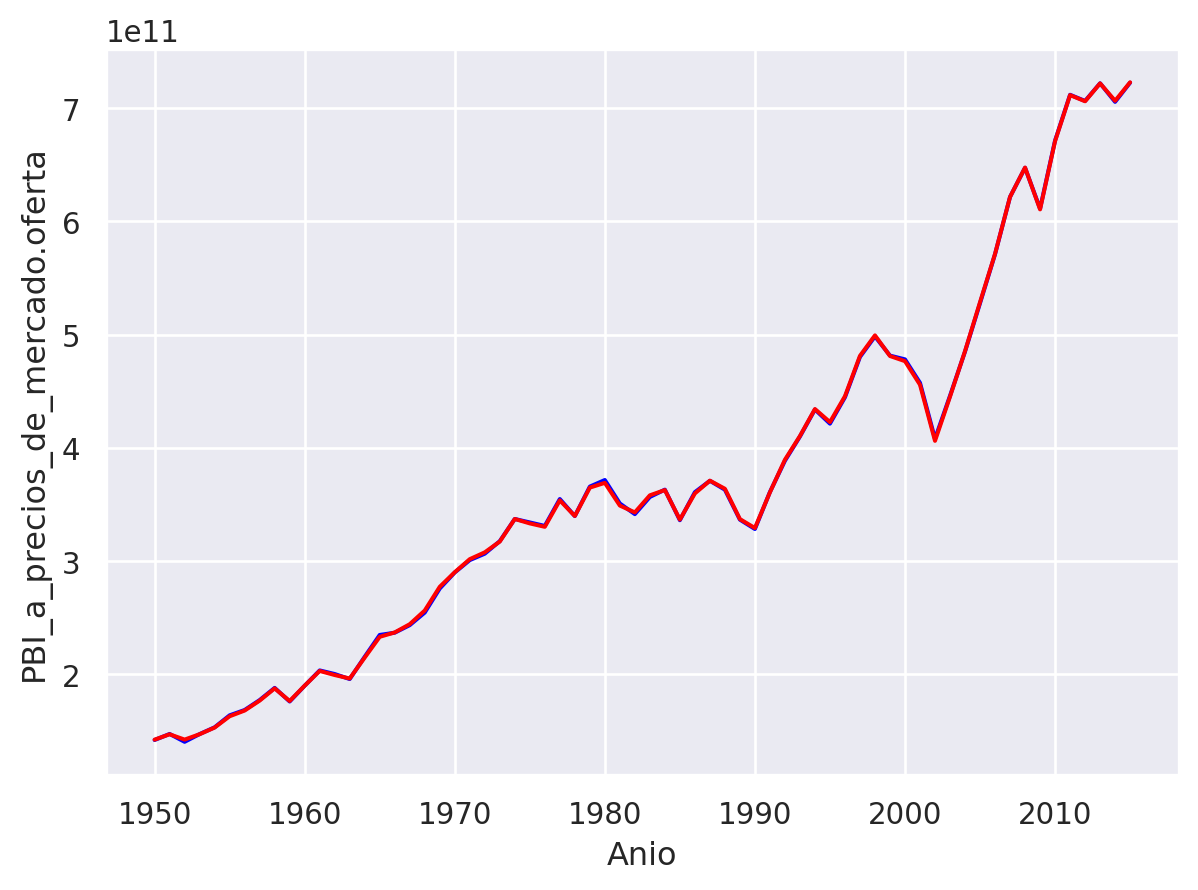

In [35]:
(
    so.Plot(macro_oferta, x=macro["Anio"])
    .add(so.Line(color="blue"), y=pbi)
    .add(so.Line(color="red"), y=pbi_pred+0e11)
)

## 2. Escalamiento lineal

Para transformar el intervalo $[2,5]$ al $[0,1]$, primero resto 2, y luego divido por $5-2 = 3$

$$x \rightarrow \frac{(x-2)}{3}$$

## 3. College Basketball

In [15]:
data = pd.read_csv("../Notebooks/CollegeBasketballPlayers2009-2021.csv")
data.head()

/tmp/ipykernel_39250/1984526907.py:1: DtypeWarning: Columns (27) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("../Notebooks/CollegeBasketballPlayers2009-2021.csv")


,player_name,team,conf,GP,Min_per,Ortg,usg,eFG,TS_per,ORB_per,...,dgbpm,oreb,dreb,treb,ast,stl,blk,pts,Unnamed: 64,Unnamed: 65
0,DeAndrae Ross,South Alabama,SB,26,29.5,97.3,16.6,42.5,44.43,1.6,...,-1.941150,0.1923,0.6154,0.8077,1.1923,0.3462,0.0385,3.8846,NaN,6.22026
1,Pooh Williams,Utah St.,WAC,34,60.9,108.3,14.9,52.4,54.48,3.8,...,-0.247934,0.6765,1.2647,1.9412,1.8235,0.4118,0.2353,5.9412,NaN,3.94375
2,Jesus Verdejo,South Florida,BE,27,72.0,96.2,21.8,45.7,47.98,2.1,...,-0.883163,0.6296,2.3333,2.9630,1.9630,0.4815,0.0000,12.1852,NaN,10.92680
3,Mike Hornbuckle,Pepperdine,WCC,30,44.5,97.7,16.0,53.6,53.69,4.1,...,-0.393459,0.7000,1.4333,2.1333,1.1000,0.5667,0.1333,4.9333,NaN,6.77427
4,Anthony Brown,Pacific,BW,33,56.2,96.5,22.0,52.8,54.31,8.3,...,-0.668318,1.4242,3.3030,4.7273,0.8485,0.4545,0.3333,7.5758,NaN,0.00000


In [16]:
pts = data.pop("pts")

In [17]:
# Me quedo con las columnas numericas
data = data.select_dtypes(include="number")

In [18]:
# Cuantas filas hay?
data.shape

(61061, 57)

In [19]:
# Me fijo nans
data.isna().sum()

GP                                     0
Min_per                                0
Ortg                                   0
usg                                    0
eFG                                    0
TS_per                                 0
ORB_per                                0
DRB_per                                0
AST_per                                0
TO_per                                 0
FTM                                    0
FTA                                    0
FT_per                                 0
twoPM                                  0
twoPA                                  0
twoP_per                               0
TPM                                    0
TPA                                    0
TP_per                                 0
blk_per                                0
stl_per                                0
ftr                                    0
porpag                                 0
adjoe                                  0
pfr             

In [20]:
# Tiro las columnas con mas de 1000 nans
data = data.dropna(axis=1, thresh=59000)

In [21]:
# Quedan 45 nans en las otras columnas. Las relleno con el promedio
data = data.fillna(data.mean())

In [22]:
# Me fijo si pts tiene nans
pts.isna().sum()

np.int64(38)

In [23]:
# Habria que tirarlos, pero los relleno con mean
pts = pts.fillna(pts.mean())

In [24]:
reg = LinearRegression()
reg.fit(data, pts)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
reg.coef_, reg.intercept_

(array([-1.28002560e-03, -1.91767067e-02, -2.35730244e-03,  5.18518633e-02,
         1.69997218e-03,  2.77785275e-03, -1.22509516e-02, -8.02426096e-03,
        -5.92709861e-03,  5.05247527e-04,  1.15786733e-02,  8.95659803e-03,
         5.68835424e-02,  3.88453652e-02,  6.28273452e-03, -1.10658163e-01,
         4.70319227e-02,  9.20869910e-03, -1.92297897e-02, -5.91666027e-03,
        -5.23270060e-02, -9.16021238e-04,  5.67439001e-01, -5.18082060e-03,
         2.40989869e-02,  3.02686627e-02,  4.82141409e-07, -3.43980433e-02,
         1.72529544e-02, -3.50729941e-01, -4.23506389e-02, -9.34250251e+01,
         9.34555452e+01,  9.34180218e+01, -1.91388581e+02,  2.53721638e-01,
         1.91420105e+02,  1.91369572e+02,  1.71812820e+01,  1.80112550e+01,
        -1.74230950e+01, -1.57197012e-01,  1.39840418e+00,  5.55374462e-01,
        -8.35392698e-03]),
 np.float64(-59.235237225113494))

In [26]:
coef_series = pd.Series(reg.coef_, index=data.columns)
coef_series.sort_values(ascending=False)

ogbpm          1.914201e+02
dgbpm          1.913696e+02
obpm           9.345555e+01
dbpm           9.341802e+01
dreb           1.801126e+01
oreb           1.718128e+01
stl            1.398404e+00
porpag         5.674390e-01
blk            5.553745e-01
mp             2.537216e-01
FT_per         5.688354e-02
usg            5.185186e-02
TPM            4.703192e-02
twoPM          3.884537e-02
year           3.026866e-02
pfr            2.409899e-02
adrtg          1.725295e-02
FTM            1.157867e-02
TPA            9.208699e-03
FTA            8.956598e-03
twoPA          6.282735e-03
TS_per         2.777853e-03
eFG            1.699972e-03
TO_per         5.052475e-04
pid            4.821414e-07
ftr           -9.160212e-04
GP            -1.280026e-03
Ortg          -2.357302e-03
adjoe         -5.180821e-03
blk_per       -5.916660e-03
AST_per       -5.927099e-03
DRB_per       -8.024261e-03
Unnamed: 65   -8.353927e-03
ORB_per       -1.225095e-02
Min_per       -1.917671e-02
TP_per        -1.922

In [27]:
# Ahora pruebo escalando las variables
scaler = MinMaxScaler()
data_transformed = scaler.fit_transform(data, pts)

In [28]:
reg_transformed = LinearRegression()
reg_transformed.fit(data_transformed, pts)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
reg_transformed.coef_, reg_transformed.intercept_

(array([-5.12010239e-02, -1.87931725e+00, -1.96599024e+00,  2.59259317e+00,
         2.54995827e-01,  4.16677913e-01, -1.93148503e+01, -1.11136014e+01,
        -5.92709861e-01,  5.05247527e-02,  3.61254606e+00,  3.34976766e+00,
         5.68835424e-02,  1.29355066e+01,  4.25969401e+00, -1.10658163e-01,
         6.91369264e+00,  3.62822745e+00, -1.92297897e-02, -6.34265981e+00,
        -6.71355487e+00, -9.16021238e-01,  8.76727303e+00, -3.71963905e+00,
         1.73512705e+01,  3.63223952e-01,  3.57999639e-02, -5.02734626e+01,
         2.47874058e+01, -2.33507858e+00, -1.52686321e+01, -7.35721139e+04,
         2.37927071e+04,  5.42551693e+04, -9.79968866e+04,  1.26860819e+01,
         7.02557726e+04,  3.44406861e+04,  1.01941700e+02,  2.07948945e+02,
        -2.61346425e+02, -1.57197012e+00,  5.59361670e+00,  2.92021446e+00,
        -1.06323770e+00]),
 np.float64(-4455.251811552342))

In [30]:
coef_series = pd.Series(reg_transformed.coef_, index=data.columns)
coef_series.sort_values(ascending=False)[:5]

ogbpm    70255.772564
dbpm     54255.169302
dgbpm    34440.686136
obpm     23792.707094
dreb       207.948945
dtype: float64